# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from collections import Counter
import re
import json

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

Number of waste categories: 9

Waste categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation

Images per category:
Cardboard: 461
Food Organics: 411
Glass: 420
Metal: 790
Miscellaneous Trash: 495
Paper: 500
Plastic: 921
Textile Trash: 318
Vegetation: 436


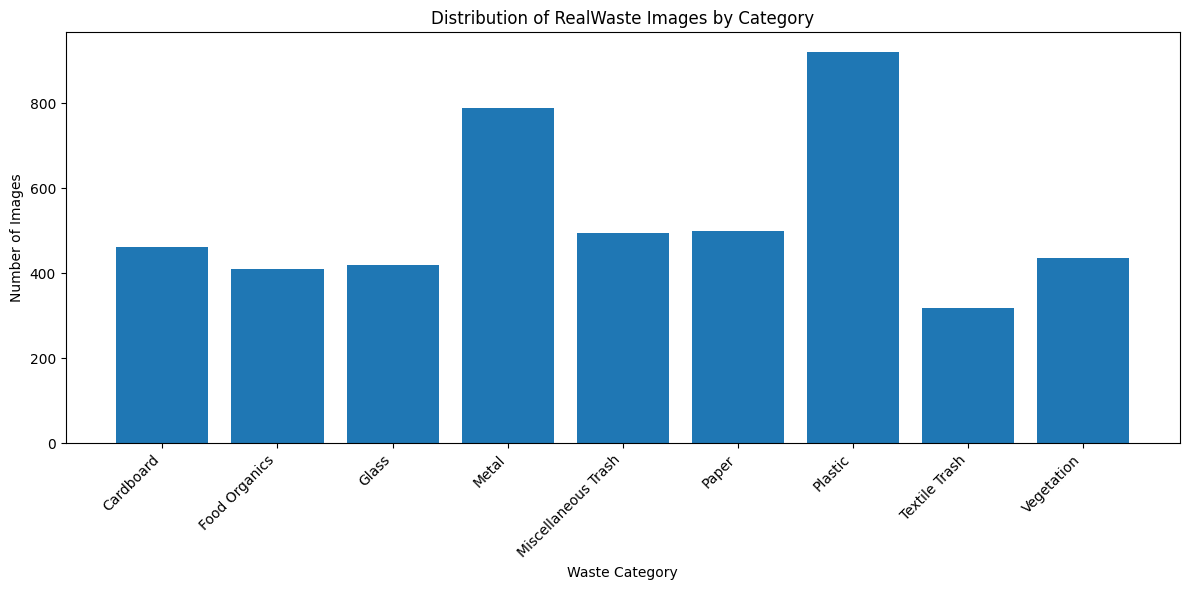


Image characteristics:
        width  height
count  4752.0  4752.0
mean    524.0   524.0
std       0.0     0.0
min     524.0   524.0
25%     524.0   524.0
50%     524.0   524.0
75%     524.0   524.0
max     524.0   524.0

Image modes:
mode
RGB    4752
Name: count, dtype: int64

Most common resolutions:
width  height
524    524       4752
dtype: int64


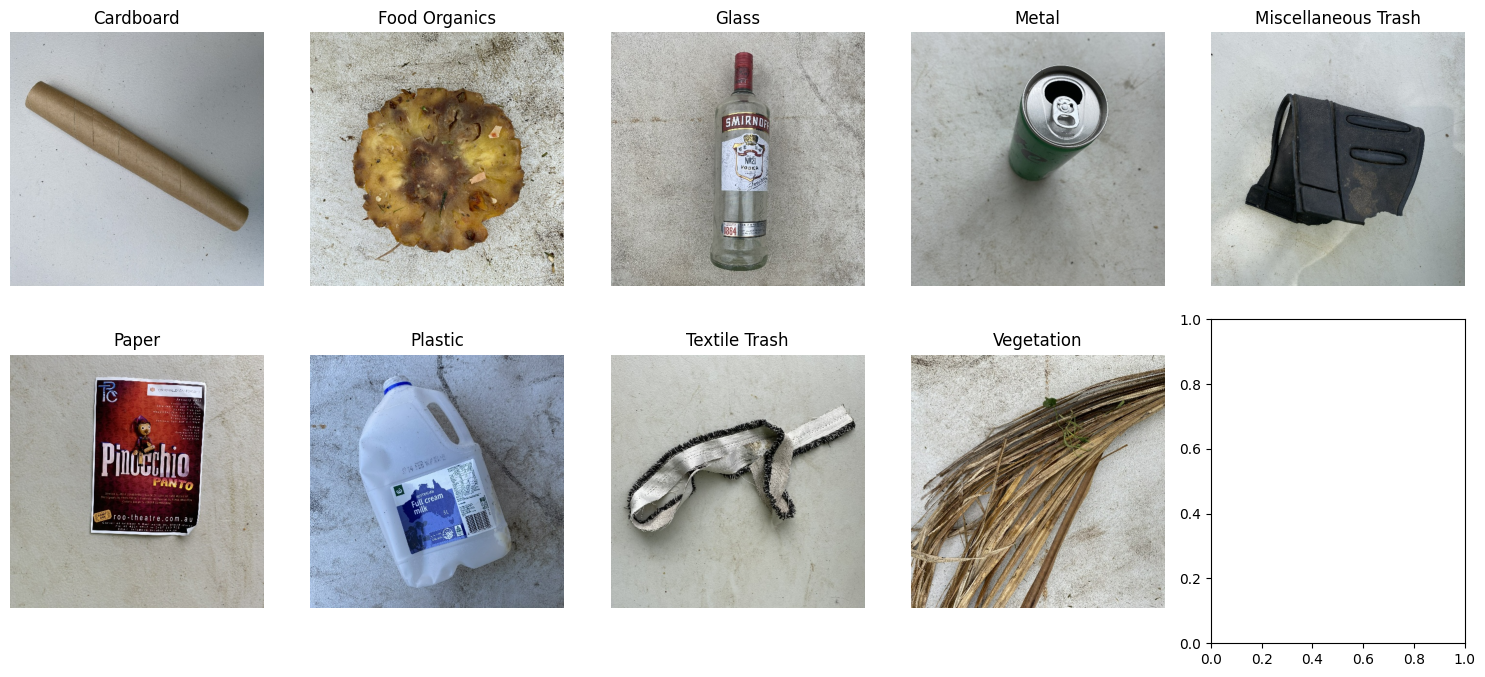

In [ ]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)


# loading the RealWaste dataset
data_dir = r"C:\Users\komucheyi\Desktop\Summative-Lab-NNs-and-Similar-Models\RealWaste"

# Exploring dataset structure
categories = sorted([
    folder for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
])

print("Number of waste categories:", len(categories))
print("\nWaste categories:")
for category in categories:
    print("-", category)


# check Distribution of waste categories
category_counts = {}

for category in categories:
    category_path = os.path.join(data_dir, category)
    images = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    category_counts[category] = len(images)

print("\nImages per category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


# Plot category distribution
plt.figure(figsize=(12, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xticks(rotation=45, ha="right")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Distribution of RealWaste Images by Category")
plt.tight_layout()
plt.show()


# Examine image characteristics
image_info = []

for category in categories:
    category_path = os.path.join(data_dir, category)

    for filename in os.listdir(category_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            filepath = os.path.join(category_path, filename)

            try:
                with Image.open(filepath) as img:
                    image_info.append({
                        "category": category,
                        "filename": filename,
                        "width": img.width,
                        "height": img.height,
                        "mode": img.mode
                    })
            except Exception as e:
                print(f"Could not read {filepath}: {e}")


# Convert image information to DataFrame
image_df = pd.DataFrame(image_info)

print("\nImage characteristics:")
print(image_df[["width", "height", "mode"]].describe())

print("\nImage modes:")
print(image_df["mode"].value_counts())

print("\nMost common resolutions:")
print(
    image_df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)


# Display sample images from different categories
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, category in enumerate(categories[:10]):
    category_path = os.path.join(data_dir, category)

    image_files = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        filepath = os.path.join(category_path, image_files[0])

        img = Image.open(filepath)

        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis("off")

plt.tight_layout()
plt.show()

### 1.2 Explore Text Datasets

Dataset shape: (5000, 5)

Column names:
['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

First 5 rows:


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB

Missing values:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64

Number of duplicate rows: 7

Dataset summary:


,description,category,disposal_instruction,common_confusion,material_composition
count,5000,5000,5000,2496,5000
unique,4939,9,44,9,9
top,spoiled food,Vegetation,Rinse container before recycling.,Invasive species may require special disposal....,Plant matter composed primarily of cellulose a...
freq,3,600,239,315,600


Total words: 25241
Unique words (vocabulary size): 309

Most common words:
with: 727
sized: 534
glass: 424
empty: 348
bottle: 342
food: 316
paper: 316
box: 313
residue: 309
plastic: 280
metal: 270
brand: 247
dry: 211
new: 196
soiled: 189
crumpled: 189
medium: 187
orange: 186
stained: 185
intact: 184

Waste category distribution:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


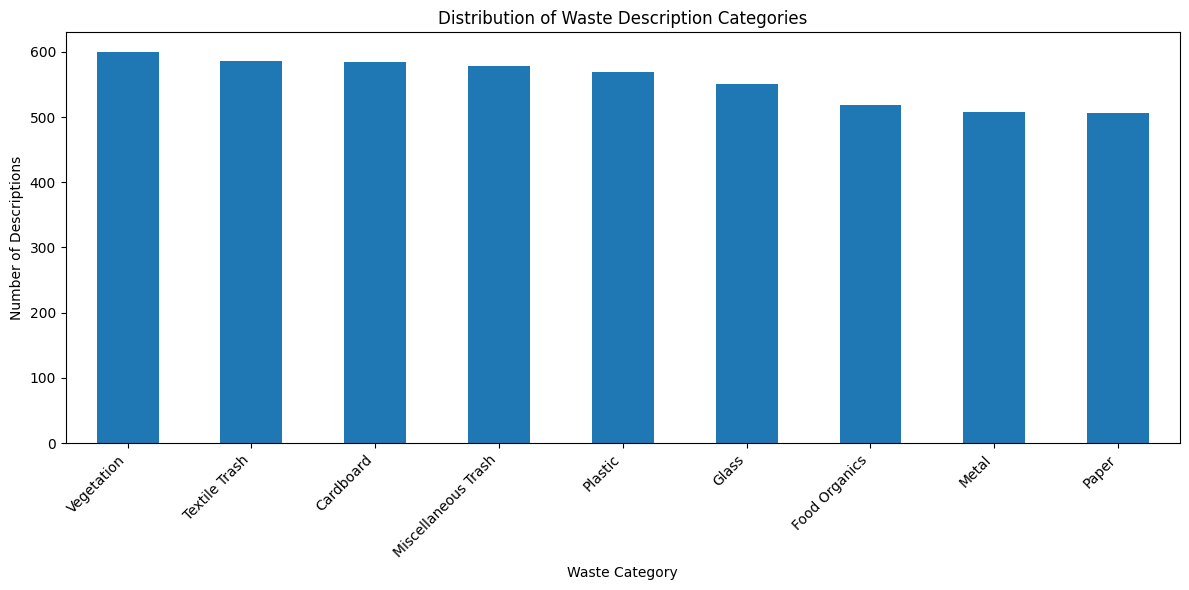

In [3]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
# Loading  dataset
df = pd.read_csv("waste_descriptions.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Summary statistics
print("\nDataset summary:")
display(df.describe(include="all"))

# Combine all descriptions into one text string
text_column = "description"
category_column = "category"

all_text = " ".join(df[text_column].dropna().astype(str))

# Convert to lowercase and extract words
words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

# Analyze vocabulary and structure
vocabulary = set(words)

print("Total words:", len(words))
print("Unique words (vocabulary size):", len(vocabulary))

# Most common words
word_counts = Counter(words)

print("\nMost common words:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

# - distribution of categories
category_counts = df[category_column].value_counts()

print("\nWaste category distribution:")
print(category_counts)

plt.figure(figsize=(12, 6))
category_counts.plot(kind="bar")
plt.xlabel("Waste Category")
plt.ylabel("Number of Descriptions")
plt.title("Distribution of Waste Description Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Dataset shape: (14, 6)

Columns:
['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']

First 5 documents:


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     object
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     object
 4   document_text       14 non-null     object
 5   jurisdiction        14 non-null     object
dtypes: int64(1), object(5)
memory usage: 800.0+ bytes

Missing values:
policy_id             0
policy_type           0
categories_covered    0
effective_date        0
document_text         0
jurisdiction          0
dtype: int64

Policy types:
policy_type
Textile Trash Recycling Guidelines          1
Glass Recycling Guidelines                  1
Food Organics Recycling Guidelines          1
Plastic Recycling Guidelines                1
Vegetation Recycling Guidelines             1
Cardbo

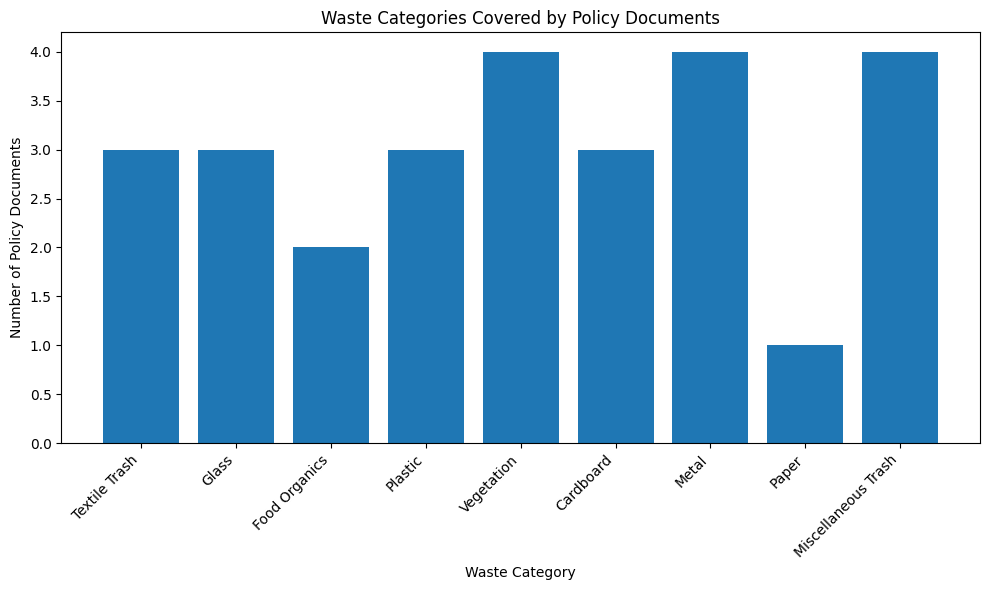

Total words: 1211
Vocabulary size: 325

Most common words:
and: 63
guidelines: 34
items: 33
recycling: 29
non: 23
containers: 23
clean: 21
glass: 21
plastic: 20
packaging: 19
cardboard: 18
acceptable: 16
or: 16
food: 16
collection: 15
paper: 15
bins: 14
metal: 14
cans: 14
in: 12
bags: 12
materials: 12
place: 11
with: 10
waste: 10

Document length statistics:
count     14.000000
mean     101.785714
std       15.115853
min       86.000000
25%       94.250000
50%       99.000000
75%      102.000000
max      146.000000
Name: word_count, dtype: float64
Policy ID: 1
Policy Type: Textile Trash Recycling Guidelines
Categories: Textile Trash
Effective Date: 2023-11-04
Jurisdiction: Metro City

Document:
TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled item

In [4]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Loading the waste policy documents
with open("waste_policy_documents.json", "r", encoding="utf-8") as file:
    policy_data = json.load(file)

# Convert JSON records to a DataFrame
policy_df = pd.DataFrame(policy_data)

print("Dataset shape:", policy_df.shape)

print("\nColumns:")
print(policy_df.columns.tolist())

print("\nFirst 5 documents:")
display(policy_df.head())

# Check basic information
print("\nDataset information:")
policy_df.info()

print("\nMissing values:")
print(policy_df.isnull().sum())

print("\nPolicy types:")
print(policy_df["policy_type"].value_counts())

print("\nJurisdictions:")
print(policy_df["jurisdiction"].value_counts())

# Flatten categories covered by all policies
all_categories = []

for categories in policy_df["categories_covered"]:
    all_categories.extend(categories)

category_counts = Counter(all_categories)

print("Waste categories covered:")
for category, count in category_counts.most_common():
    print(f"{category}: {count}")

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.keys(),
    category_counts.values()
)

plt.xlabel("Waste Category")
plt.ylabel("Number of Policy Documents")
plt.title("Waste Categories Covered by Policy Documents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Combine all policy documents
all_text = " ".join(
    policy_df["document_text"].astype(str)
)

# Convert to lowercase and extract words
words = re.findall(
    r"\b[a-zA-Z]+\b",
    all_text.lower()
)

vocabulary = set(words)

print("Total words:", len(words))
print("Vocabulary size:", len(vocabulary))

print("\nMost common words:")
word_counts = Counter(words)

for word, count in word_counts.most_common(25):
    print(f"{word}: {count}")

# Number of words in each policy document
policy_df["word_count"] = policy_df["document_text"].apply(
    lambda x: len(str(x).split())
)

print("\nDocument length statistics:")
print(policy_df["word_count"].describe())

for _, row in policy_df.iterrows():
    print("=" * 80)
    print(f"Policy ID: {row['policy_id']}")
    print(f"Policy Type: {row['policy_type']}")
    print(f"Categories: {', '.join(row['categories_covered'])}")
    print(f"Effective Date: {row['effective_date']}")
    print(f"Jurisdiction: {row['jurisdiction']}")
    print("\nDocument:")
    print(row["document_text"][:500])
    print()

### 1.3 Create Data Pipelines

In [5]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [6]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# Your code here
# Load the waste descriptions dataset
waste_text = pd.read_csv("waste_descriptions.csv")

# Inspect the columns
print(waste_text.head())
print(waste_text.columns)

# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Clean text
waste_text["clean_text"] = waste_text["description"].apply(clean_text)

print(waste_text[["description", "clean_text"]].head())

# Features and target
X = waste_text["clean_text"]
y = waste_text["category"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)


                                         description       category  \
0                           soiled silver tablecloth  Textile Trash   
1                        folded glass bottle leaking          Glass   
2  large Supermarket vegetable waste with food re...  Food Organics   
3                         intact floral carpet piece  Textile Trash   
4                  empty fun-sized purple apple core  Food Organics   

                                disposal_instruction  \
0  Look for textile recycling programs in your area.   
1     Remove caps, lids, and corks before recycling.   
2   If no compost available, place in general waste.   
3  Look for textile recycling programs in your area.   
4           Keep separate from recyclable materials.   

                                    common_confusion  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3           

In [7]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

from sentence_transformers import SentenceTransformer

# Load the policy documents
with open("waste_policy_documents.json", "r", encoding="utf-8") as f:
    policy_documents = json.load(f)

print(f"Number of documents: {len(policy_documents)}")

# - Document preprocessing
# Preview the first document
print(policy_documents[0])

def clean_document(text):
    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Create clean text while preserving the original documents
for document in policy_documents:
    document["clean_text"] = clean_document(document["document_text"])

print(policy_documents[0]["clean_text"])

# Load the embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Extract the cleaned text
documents_text = [
    document["clean_text"]
    for document in policy_documents
]

# Create embeddings
document_embeddings = embedding_model.encode(
    documents_text,
    show_progress_bar=True
)

print("Embedding shape:", document_embeddings.shape)

Number of documents: 14
{'policy_id': 1, 'policy_type': 'Textile Trash Recycling Guidelines', 'categories_covered': ['Textile Trash'], 'effective_date': '2023-11-04', 'document_text': 'TEXTILE RECYCLING GUIDELINES\n\nAcceptable Items:\n- Clean clothing (all conditions)\n- Towels, sheets, and linens\n- Fabric scraps\n- Curtains and cloth napkins\n- Handbags and backpacks made of fabric\n- Soft toys and stuffed animals\n\nNon-Acceptable Items:\n- Wet or moldy textiles\n- Heavily soiled items\n- Carpets and rugs\n- Footwear\n- Items with significant non-textile parts\n\nCollection Method:\nPlace items in dedicated textile recycling bins or donate to local thrift stores.\n\nPreparation Instructions:\n- Ensure all items are clean and dry\n- Remove non-textile components when possible\n- Bag similar items together\n\nBenefits:\nTextile recycling conserves resources and reduces landfill waste.', 'jurisdiction': 'Metro City'}
textile recycling guidelines acceptable items: - clean clothing (all

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (14, 384)


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [ ]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 2.4 Fine-tune the Model

In [ ]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.